In [1]:
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

"""
0: Move left

1: Move down

2: Move right

3: Move up
"""


GAMMA = 0.99
MAX_EVAL_ITERS = 10
NUM_MC_EPISODES = 30
MAX_ITER = 2000
NUM_EPISODES = 1000

SIZE = 8

In [2]:
def build_env(map_name: str = f"{SIZE}x{SIZE}", slippery: bool = True):
    # Fixed the reward_schedule error (Gymnasium FrozenLake doesn't accept reward_schedule by default)
    return gym.make("FrozenLake-v1", map_name=map_name, is_slippery=slippery, reward_schedule=(10, -5, -0.2))


def extract_model(env: gym.Env):
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    transition = np.zeros((n_states, n_actions, n_states), dtype=float)
    reward = np.zeros((n_states, n_actions, n_states), dtype=float)

    for state in range(n_states):
        for action in range(n_actions):
            for prob, next_state, r, _terminated in env.unwrapped.P[state][action]:
                transition[state, action, next_state] += prob
                reward[state, action, next_state] = r

    expected_reward = np.sum(transition * reward, axis=2)
    return transition, reward, expected_reward

In [3]:
def policy_iter(env, eval_method, num_iterations=MAX_ITER):
    policy = np.zeros((env.observation_space.n), dtype=int)
    safe_states = []
    for i in range(env.observation_space.n):
        row, col = divmod(i, SIZE)
        # print(str(env.unwrapped.desc[row, col]))
        if env.unwrapped.desc[row, col] in [b'S', b'F']:
            safe_states.append(i)

    for iter in range(num_iterations):
        q_matrix = eval_method(env, policy, safe_states=safe_states)
        new_policy = np.argmax(q_matrix, axis=1)

        if np.array_equal(policy, new_policy):
            print("Converged")
            break

        policy = new_policy

    return policy

In [4]:
def q_values_from_values(transition_matrix, reward_matrix, value_matrix):
    # reward: s x a x s
    # transition: s x a x s
    # value: s
    q_values = np.sum(reward_matrix * transition_matrix, axis=2) + GAMMA * np.einsum("sat, t -> sa", transition_matrix, value_matrix)
    return q_values

In [5]:
def oneshot_eval(env, policy, safe_states=None):
    transition_matrix, reward_matrix, expected_reward_matrix = extract_model(env)
    """V = R + Gamma * P * V (shapes upar niche)
    thus, V = ((I - Gamma*P)^(-1)) * R

    these are after 'coompressing' the original env matrices (3d) by one dim to
    account for the policy's choice
    """
    policy_expected_reward_matrix = expected_reward_matrix[np.arange(env.observation_space.n), policy]
    policy_transition_matrix = transition_matrix[np.arange(env.observation_space.n), policy, :]
    # value_matrix = np.linalg.inv(np.eye(env.observation_space.n) - GAMMA * policy_transition_matrix) @ policy_expected_reward_matrix

    value_matrix = np.linalg.solve(
        np.eye(env.observation_space.n) - GAMMA * policy_transition_matrix,
        policy_expected_reward_matrix
    )

    print(transition_matrix.shape, reward_matrix.shape, value_matrix.shape)
    q_values = q_values_from_values(transition_matrix, reward_matrix, value_matrix)

    return q_values

In [6]:
def plot_frozenlake_policy(policy, desc):
    """
    policy: (N,N) array of actions
    desc:   (N,N) array containing b'S', b'F', b'H', b'G'
    """

    nrows, ncols = desc.shape

    fig, ax = plt.subplots(figsize=(ncols, nrows))

    arrows = {
        0: "←",  # left
        1: "↓",  # down
        2: "→",  # right
        3: "↑",  # up
    }

    for r in range(nrows):
        for c in range(ncols):

            tile = desc[r, c]

            # background color
            if tile == b'H':
                color = "black"
            elif tile == b'G':
                color = "green"
            elif tile == b'S':
                color = "lightblue"
            else:
                color = "white"

            rect = plt.Rectangle(
                (c, nrows - r - 1),
                1,
                1,
                facecolor=color,
                edgecolor="gray",
            )
            ax.add_patch(rect)

            if tile == b'H':
                ax.text(
                    c + 0.5,
                    nrows - r - 0.5,
                    "H",
                    ha="center",
                    va="center",
                    fontsize=18,
                    color="white",
                    fontweight="bold",
                )

            elif tile == b'G':
                ax.text(
                    c + 0.5,
                    nrows - r - 0.5,
                    "G",
                    ha="center",
                    va="center",
                    fontsize=18,
                    fontweight="bold",
                )

            else:
                ax.text(
                    c + 0.5,
                    nrows - r - 0.5,
                    arrows[policy[r, c]],
                    ha="center",
                    va="center",
                    fontsize=20,
                )

    ax.set_xlim(0, ncols)
    ax.set_ylim(0, nrows)
    ax.set_aspect("equal")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64) (64, 4, 64) (64,)
(64, 4, 64

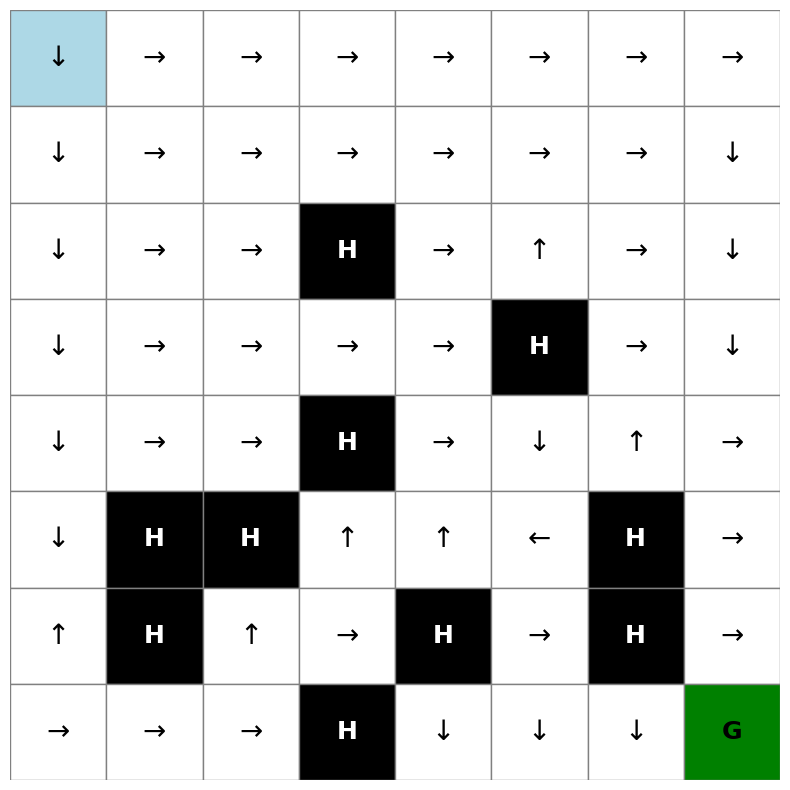

"\nNote: maybe starting with an all 0 policy isn't always good\nstarting with that policy on this map for MC evaluation leads to no updates,\nunless you change the reward schedule to penalize ice and holes\n\nAlso, somehow MC and oneshot give different answers, with oneshot being worse?\n"

In [7]:
"""Here, change oneshot_eval to monte_carlo_eval to switch evaluation modes"""

env = build_env(slippery=True)
policy = policy_iter(env, eval_method=oneshot_eval)
policy = np.reshape(policy, (SIZE, SIZE))
print(policy)

print(env.unwrapped.desc)

plot_frozenlake_policy(policy, env.unwrapped.desc)

"""
Note: maybe starting with an all 0 policy isn't always good
starting with that policy on this map for MC evaluation leads to no updates,
unless you change the reward schedule to penalize ice and holes

Also, somehow MC and oneshot give different answers, with oneshot being worse?
"""

In [8]:
def value_iteration(env, max_iters=MAX_ITER, theta=1):
    transition_matrix, reward_matrix, expected_reward_matrix = extract_model(env)
    v_matrix = np.zeros((env.observation_space.n))
    for iter in range(max_iters):
        v_new = np.max(np.sum(transition_matrix * (reward_matrix + GAMMA * v_matrix), axis=2), axis=1)
        delta = np.max(np.abs(v_new - v_matrix))
        # if delta < theta:
        #     break
        v_matrix = v_new

    optimal_policy = np.argmax(np.sum(transition_matrix * (reward_matrix + GAMMA * v_matrix), axis=2), axis=1)
    return v_matrix, optimal_policy

[[-5.89086697 -5.46385032 -4.98426729 -4.45255629 -3.87941803 -3.3757387
  -2.98659018 -2.83917494]
 [-5.89033413 -5.50294397 -5.06095608 -4.55455989 -3.89459488 -3.26112173
  -2.61844753 -2.31914994]
 [-5.85015867 -5.54472077 -5.19134277  0.         -4.0552023  -3.28194023
  -2.02288878 -1.48406901]
 [-5.7268135  -5.50183679 -5.2158402  -4.88694572 -4.50589611  0.
  -1.42138884 -0.38416043]
 [-5.5192694  -5.30561114 -5.12122727  0.         -4.14448289 -3.1416412
  -1.29412908  1.24748736]
 [-5.29411765  0.          0.         -4.82079558 -4.30544114 -3.47545226
   0.          3.5229984 ]
 [-5.29411765  0.         -5.04698464 -4.99086254  0.         -2.47853057
   0.          6.51132757]
 [-5.48407947 -5.23416491 -5.17239542  0.         -1.98750945  1.419299
   5.47517712  0.        ]]
[[1 2 2 2 2 2 2 2]
 [1 2 2 2 2 2 2 1]
 [1 2 2 0 2 3 2 1]
 [1 2 2 2 2 0 2 1]
 [1 2 2 0 2 1 3 2]
 [1 0 0 3 3 0 0 2]
 [3 0 3 2 0 0 0 2]
 [2 2 2 0 1 1 1 0]]
[[b'S' b'F' b'F' b'F' b'F' b'F' b'F' b'F']
 [b'F' 

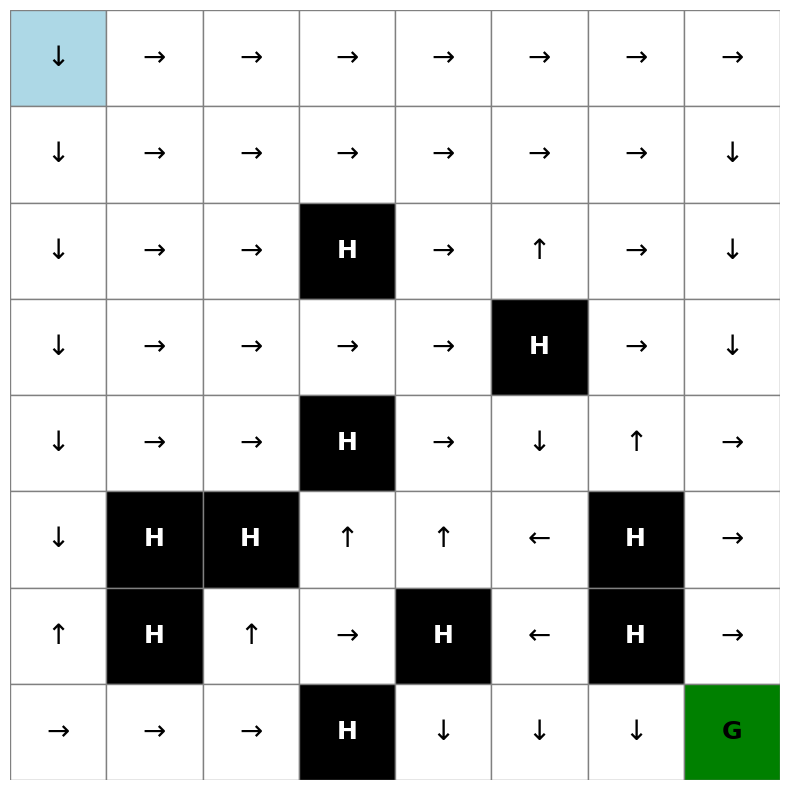

In [9]:
if __name__ == "__main__":

    """Here, change oneshot_eval to monte_carlo_eval to switch evaluation modes"""

    env = build_env(slippery=True)
    # policy = policy_iter(env, eval_method=oneshot_eval)
    values, policy = value_iteration(env, max_iters=MAX_ITER)
    values = np.reshape(values, (SIZE, SIZE))
    print(values)
    policy = np.reshape(policy, (SIZE, SIZE))
    print(policy)

    print(env.unwrapped.desc)

    plot_frozenlake_policy(policy, env.unwrapped.desc)

    """How to tune theta in convergence test?"""